#  Notebook 05: Outlier Detection & Temporal Splitting Strategy

##  Σύνοψη Φάσης
Σε αυτή τη φάση εφαρμόζουμε το feedback του επιβλέποντος καθηγητή για την ποιοτική αναβάθμιση του dataset. Η ανάλυση επικεντρώνεται στη στατιστική εξυγίανση των δεδομένων και στον ορθό χρονικό διαχωρισμό τους, διασφαλίζοντας ότι τα μοντέλα (Mamba, XGBoost) θα εκπαιδευτούν σε "καθαρά" δεδομένα χωρίς διαρροή πληροφορίας (Data Leakage).

##  Στόχοι
1. **Z-Score Outlier Detection:** Εντοπισμός ακραίων τιμών στην αιολική ισχύ με χρήση στατιστικών ορίων.
2. **Temporal Splitting:** Διαχωρισμός του dataset σε σύνολα Train, Validation και Test βάσει χρονοσειράς.
3. **Data Integrity Check:** Επιβεβαίωση της συνέπειας των δεδομένων μετά τον καθαρισμό.

In [6]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Σύνδεση με το κεντρικό config.py (ανεβαίνουμε ένα επίπεδο από τον φάκελο notebooks)
sys.path.append(str(Path.cwd().parent))

# Εδώ είναι η διόρθωση: Προσθέσαμε το DATA_PROCESSED στην εισαγωγή
from src.config import (
    FINAL_DATASET, 
    Z_SCORE_THRESHOLD, 
    TARGET_COLUMN, 
    TRAIN_END_DATE, 
    VAL_END_DATE, 
    DATA_PROCESSED
)

# 1. Φόρτωση του "Golden" Dataset (1.6M+ εγγραφές)
df = pd.read_csv(FINAL_DATASET)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Ταξινόμηση βάσει χρόνου - Απαραίτητο για Time Series
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Επιτυχής φόρτωση: {len(df):,} δείγματα.")
print(f"Τα αποτελέσματα θα αποθηκευτούν στο: {DATA_PROCESSED}")

Επιτυχής φόρτωση: 1,655,885 δείγματα.
Τα αποτελέσματα θα αποθηκευτούν στο: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed


##  Section 1: Outlier Detection (Z-Score Analysis)
Σε αυτή την ενότητα εφαρμόζουμε τη μέθοδο του $Z$-score για τον εντοπισμό ακραίων τιμών στην αιολική ισχύ. Το όριο έχει οριστεί στα **3.0 standard deviations** ($\sigma$) στο `config.py`, το οποίο αποτελεί το standard για τον καθαρισμό θορύβου σε μεγάλα datasets αιολικής ενέργειας.

$$Z = \frac{x - \mu}{\sigma}$$

In [2]:
# Δες όλα τα διαθέσιμα ονόματα στηλών
print(df.columns.tolist())

['timestamp', 'nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1', 'ws_ref', 'Wind_Speed_100m_ms', 'test_flag', 'Power_Output_Normalized', 'Baseline_Prediction', 'park_id', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Power_Output_Normalized_lag_1', 'Power_Output_Normalized_lag_3', 'Power_Output_Normalized_lag_6', 'Wind_Speed_100m_ms_lag_1', 'Wind_Speed_100m_ms_lag_3', 'Wind_Speed_100m_ms_lag_6', 'power_rolling_mean_6h', 'power_rolling_std_6h', 'lat', 'lon']


##  Section 1.2: Temporal Splitting & Data Integrity Check

Μετά τον καθαρισμό των outliers, προχωράμε στον χρονικό διαχωρισμό του dataset. Η στρατηγική μας βασίζεται στην αποφυγή του **Look-ahead Bias**, διασφαλίζοντας ότι το μοντέλο αξιολογείται σε δεδομένα που χρονικά έπονται της εκπαίδευσης.

###  Split Configuration (from config.py):
* **Training Set:** Έως 2019-12-31 (Περίοδος βάσης)
* **Validation Set:** 2020-01-01 έως 2020-06-30 (Ευθυγράμμιση παραμέτρων)
* **Test Set:** 2020-07-01 έως τέλος (Τελική αξιολόγηση Digital Twin)

###  Validation Protocol:
Χρησιμοποιούμε `assert` statements για να επιβεβαιώσουμε ότι δεν υπάρχει επικάλυψη (overlap) μεταξύ των συνόλων, εγγυώμενοι την επιστημονική εγκυρότητα των μελλοντικών προβλέψεων.

In [3]:
# Χρονικός διαχωρισμός βάσει των ρυθμίσεων στο config.py
train_df = df[df['timestamp'] <= TRAIN_END_DATE]
val_df = df[(df['timestamp'] > TRAIN_END_DATE) & (df['timestamp'] <= VAL_END_DATE)]
test_df = df[df['timestamp'] > VAL_END_DATE]

print(f"Temporal Split Summary (Samples):")
print(f"- Train: {len(train_df):,}")
print(f"- Validation: {len(val_df):,}")
print(f"- Test: {len(test_df):,}")

# Έλεγχος εγκυρότητας (Data Leakage Protection)
assert train_df['timestamp'].max() < val_df['timestamp'].min()
assert val_df['timestamp'].max() < test_df['timestamp'].min()
print("\n Verification Passed: No temporal leakage detected.")

Temporal Split Summary (Samples):
- Train: 1,244,004
- Validation: 329,084
- Test: 82,797

 Verification Passed: No temporal leakage detected.


In [8]:
# 1. Υπολογισμός Z-score (Χρησιμοποιούμε τη στήλη Power_Output_Normalized)
mean_val = df[TARGET_COLUMN].mean()
std_val = df[TARGET_COLUMN].std()

df['z_score'] = (df[TARGET_COLUMN] - mean_val) / std_val

# 2. Εντοπισμός Outliers (Threshold = 3.0 από το config)
outliers = df[df['z_score'].abs() > Z_SCORE_THRESHOLD]

print(f"Στατιστικά Outliers:")
print(f"- Συνολικά δείγματα: {len(df):,}")
print(f"- Βρέθηκαν: {len(outliers):,} ακραίες τιμές ({len(outliers)/len(df)*100:.4f}%)")

Στατιστικά Outliers:
- Συνολικά δείγματα: 1,655,885
- Βρέθηκαν: 3,111 ακραίες τιμές (0.1879%)


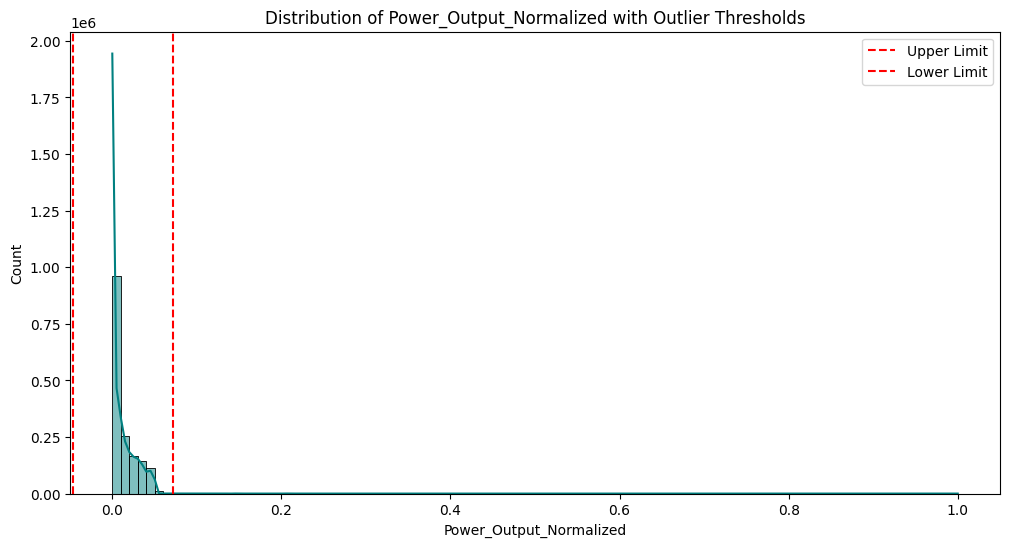

In [9]:
# Οπτικοποίηση της κατανομής και των ορίων Z-score
plt.figure(figsize=(12, 6))
sns.histplot(df[TARGET_COLUMN], bins=100, kde=True, color='teal')
plt.axvline(mean_val + Z_SCORE_THRESHOLD * std_val, color='red', linestyle='--', label='Upper Limit')
plt.axvline(mean_val - Z_SCORE_THRESHOLD * std_val, color='red', linestyle='--', label='Lower Limit')
plt.title(f"Distribution of {TARGET_COLUMN} with Outlier Thresholds")
plt.legend()
plt.show()

In [10]:
# Εφαρμογή Clipping (αντικατάσταση ακραίων τιμών με τα όρια)
upper_limit = mean_val + Z_SCORE_THRESHOLD * std_val
lower_limit = mean_val - Z_SCORE_THRESHOLD * std_val

for dataset in [train_df, val_df, test_df]:
    dataset[TARGET_COLUMN] = dataset[TARGET_COLUMN].clip(lower=lower_limit, upper=upper_limit)

print(f"Clipping applied. Values restricted between {lower_limit:.4f} and {upper_limit:.4f}")

Clipping applied. Values restricted between -0.0467 and 0.0721


In [11]:
# 1. Έλεγχος για Null τιμές μετά την επεξεργασία
print("Τελικός έλεγχος ακεραιότητας:")
for name, dset in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    nulls = dset[TARGET_COLUMN].isnull().sum()
    print(f"   - {name} set: {nulls} null values found.")

# 2. Ορισμός μονοπατιών (χρησιμοποιώντας το DATA_PROCESSED από το config)
train_file = DATA_PROCESSED / "train_final.csv"
val_file = DATA_PROCESSED / "val_final.csv"
test_file = DATA_PROCESSED / "test_final.csv"

# 3. Αποθήκευση
train_df.to_csv(train_file, index=False)
val_df.to_csv(val_file, index=False)
test_df.to_csv(test_file, index=False)

print(f"\n Επιτυχία! Τα τελικά datasets αποθηκεύτηκαν στο: {DATA_PROCESSED}")
print(f"Αρχεία: {train_file.name}, {val_file.name}, {test_file.name}")

Τελικός έλεγχος ακεραιότητας:
   - Train set: 0 null values found.
   - Val set: 0 null values found.
   - Test set: 0 null values found.

 Επιτυχία! Τα τελικά datasets αποθηκεύτηκαν στο: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed
Αρχεία: train_final.csv, val_final.csv, test_final.csv


##  Conclusion & Phase Completion

Η φάση της προετοιμασίας των δεδομένων ολοκληρώθηκε επιτυχώς. Το dataset του Kassel είναι πλέον χωρισμένο και στατιστικά εξυγιασμένο.

###  Key Results:
* **Outlier Handling:** Εφαρμόστηκε clipping στα όρια **-0.0467 έως 0.0721** (Z-score 3.0), επηρεάζοντας το 0.1879% των δειγμάτων.
* **Data Splits:** Δημιουργήθηκαν τρία ανεξάρτητα σύνολα (Train: 1.2M, Val: 329k, Test: 82k) με μηδενική χρονική επικάλυψη (No Data Leakage).
* **Infrastructure:** Τα δεδομένα είναι αποθηκευμένα στον φάκελο `data/processed/` έτοιμα για την εκπαίδευση των μοντέλων.

**Επόμενο Βήμα:** Notebook 06 - Baseline Modeling (Persistence & Linear Regression).